# Ejercicio Práctico - Análisis de Ventas con PySpark


In [1]:
# Permite usar pyspark en entornos locales que no tienen configuradas las rutas de Spark
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, sum as spark_sum, desc, round, count, when, trim
import pyspark.sql.functions as F
import numpy as np
import pandas as pd

In [3]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("Sales Analysis") \
    .master("local[*]") \
    .getOrCreate()

# Orders dataset
raw = """ 
 1        , 100         , 2023-01-04 10:23 , 120.50       , SHIPPED   
 2        , 101         , 2023-01-10 12:10 , 89.99        , CANCELLED 
 3        , 102         , 2023-01-11 09:01 , 42.10        , SHIPPED   
 4        , 101         , 2023-02-02 14:55 , 150.00       , SHIPPED   
 5        , 103         , 2023-02-15 18:20 , 230.00       , RETURNED  
 6        , 100         , 2023-02-18 16:45 , 70.00        , SHIPPED   
 7        , 104         , 2023-03-03 11:30 , 15.99        , SHIPPED   
 8        , 103         , NULL             , 199.99       , SHIPPED   
 9        , NULL        , 2023-03-09 17:25 , 310.00       , SHIPPED   
 10       , 104         , 2023-03-22 09:15 , -50.00       , SHIPPED   
"""

data = [
    tuple(None if x.strip() == "NULL" else x for x in line.split(","))
    for line in raw.strip().split("\n")
]

cols = ["order_id", "customer_id", "order_date", "total_amount", "status"]

orders = spark.createDataFrame(data, cols)
orders.show()

# Customers dataset
raw = """
 100        ,  Anna  ,  Spain  ,  2022-11-01 
 101        ,  Miguel,  Mexico ,  2023-02-10 
 102        ,  Julia ,  Italy  ,  2021-09-12 
 103        ,  Lucia ,  Spain  ,  2020-03-05 
 104        ,  Anna  ,  Spain  ,  2022-11-01
 104        ,  Anna  ,  Spain  ,  2022-11-01
 105        ,  Carlos,  Brazil ,  NULL       
"""
data = [
    tuple(None if x.strip() == "NULL" else x for x in line.split(","))
    for line in raw.strip().split("\n")
]

cols = ["customer_id", "name", "country", "signup_date"]

customers= spark.createDataFrame(data, cols)
customers.show()

+----------+-------------+------------------+--------------+-----------+
|  order_id|  customer_id|        order_date|  total_amount|     status|
+----------+-------------+------------------+--------------+-----------+
| 1        | 100         | 2023-01-04 10:23 | 120.50       | SHIPPED   |
| 2        | 101         | 2023-01-10 12:10 | 89.99        | CANCELLED |
| 3        | 102         | 2023-01-11 09:01 | 42.10        | SHIPPED   |
| 4        | 101         | 2023-02-02 14:55 | 150.00       | SHIPPED   |
| 5        | 103         | 2023-02-15 18:20 | 230.00       | RETURNED  |
| 6        | 100         | 2023-02-18 16:45 | 70.00        | SHIPPED   |
| 7        | 104         | 2023-03-03 11:30 | 15.99        | SHIPPED   |
| 8        | 103         |              NULL| 199.99       | SHIPPED   |
| 9        |         NULL| 2023-03-09 17:25 | 310.00       | SHIPPED   |
| 10       | 104         | 2023-03-22 09:15 | -50.00       |    SHIPPED|
+----------+-------------+------------------+------

## 1) Limpieza y Preparación de Datos

In [4]:
# ORDERS DATASET - LIMPIEZA Y PREPARACIÓN DE DATOS
# Variables y tipos
orders.printSchema()

# Contar valores nulos por columna
orders.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) for c in orders.columns
]).show()

# Corregir tipo de variables
orders = orders.withColumn("order_id", col("order_id").cast("int")) \
    .withColumn("customer_id", col("customer_id").cast("int")) \
    .withColumn("order_date", col("order_date").cast("timestamp")) \
    .withColumn("total_amount", col("total_amount").cast("float")) \
    .withColumn("status", trim(col("status"))) # Eliminar espacios en status 
orders.printSchema()

print("La tabla orders tiene {} filas y {} columnas".format(orders.count(), len(orders.columns)))

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- total_amount: string (nullable = true)
 |-- status: string (nullable = true)

+--------+-----------+----------+------------+------+
|order_id|customer_id|order_date|total_amount|status|
+--------+-----------+----------+------------+------+
|       0|          1|         1|           0|     0|
+--------+-----------+----------+------------+------+

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- status: string (nullable = true)

La tabla orders tiene 10 filas y 5 columnas


In [5]:
# CUSTOMERS DATASET - LIMPIEZA Y PREPARACIÓN DE DATOS
# Variables y tipos
customers.printSchema()

# Contar valores nulos por columna
customers.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) for c in customers.columns
]).show()

# Corregir tipo de variables
customers = customers.withColumn("customer_id", col("customer_id").cast("int")) \
                     .withColumn("signup_date", col("signup_date").cast("date")) \
                     .withColumn("name", trim(col("name"))) \
                     .withColumn("country", trim(col("country")))

customers.printSchema()
print("La tabla customers tiene {} filas y {} columnas".format(customers.count(), len(customers.columns)))

root
 |-- customer_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: string (nullable = true)

+-----------+----+-------+-----------+
|customer_id|name|country|signup_date|
+-----------+----+-------+-----------+
|          0|   0|      0|          1|
+-----------+----+-------+-----------+

root
 |-- customer_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)

La tabla customers tiene 7 filas y 4 columnas


In [ ]:
# OPCIÓN 2 DE LO ANTERIOR
from pyspark.sql.functions import col, trim

casts = {
    "order_id": "int",
    "customer_id": "int",
    "order_date": "timestamp",
    "total_amount": "float"
}

orders_casted = orders

for column, dtype in casts.items():
    orders_casted = orders_casted.withColumn(column, col(column).cast(dtype))

# Aplicar trim a "status"
orders_casted = orders_casted.withColumn("status", trim(col("status")))

orders_casted.printSchema()


In [6]:
# Eliminar filas con ids nulos
orders = orders.filter(col("customer_id").isNotNull() & col("order_id").isNotNull())
customers = customers.filter(col("customer_id").isNotNull())

# Eliminar duplicados
orders = orders.dropDuplicates()
customers = customers.dropDuplicates()

orders = orders.filter(col("total_amount") >= 0)
orders = orders.filter(~col("status").isin("CANCELLED", "RETURNED"))

print("Después de la limpieza:")
print("La tabla orders tiene {} filas y {} columnas".format(orders.count(), len(orders.columns)))
print("La tabla customers tiene {} filas y {} columnas".format(customers.count(), len(customers.columns)))

Después de la limpieza:
La tabla orders tiene 6 filas y 5 columnas
La tabla customers tiene 6 filas y 4 columnas


## 2) Transformaciones básicas

In [7]:
# Crear columna de mes
orders = orders.withColumn("month", F.month(col("order_date")))
orders = orders.withColumn("sales", col("total_amount"))

## 3) Joins

In [8]:
df = orders.join(customers, on="customer_id", how="inner")
df.printSchema()
print("La tabla resultante tiene {} filas y {} columnas".format(df.count(), len(df.columns)))

root
 |-- customer_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- order_date: timestamp (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- status: string (nullable = true)
 |-- month: integer (nullable = true)
 |-- sales: float (nullable = true)
 |-- name: string (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)

La tabla resultante tiene 6 filas y 10 columnas


## 4) EDA Básico

In [9]:
# Número de pedidos por país
df.groupBy("Country")\
  .count()\
  .show()

# Ventas totales por país
df.groupBy("Country")\
.agg(round(spark_sum("sales"),2).alias("total_sales"))\
.orderBy(desc("total_sales"))\
.show()

# Ventas totales por mes
df.groupBy("month")\
.agg(round(spark_sum("sales"),2).alias("total_sales"))\
.orderBy("month")\
.show()

# Top 3 países con más ingresos
df.groupBy("country")\
.agg(round(spark_sum("sales"),2).alias("total_sales"))\
.orderBy(desc("total_sales"))\
.limit(3)\
.show()

+-------+-----+
|Country|count|
+-------+-----+
|  Italy|    1|
|  Spain|    4|
| Mexico|    1|
+-------+-----+

+-------+-----------+
|Country|total_sales|
+-------+-----------+
|  Spain|     406.48|
| Mexico|      150.0|
|  Italy|       42.1|
+-------+-----------+

+-----+-----------+
|month|total_sales|
+-----+-----------+
| NULL|     199.99|
|    1|      162.6|
|    2|      220.0|
|    3|      15.99|
+-----+-----------+

+-------+-----------+
|country|total_sales|
+-------+-----------+
|  Spain|     406.48|
| Mexico|      150.0|
|  Italy|       42.1|
+-------+-----------+



## 5) Gráficos

<Axes: title={'center': 'Ventas mensuales'}, xlabel='Mes', ylabel='Ventas Totales'>

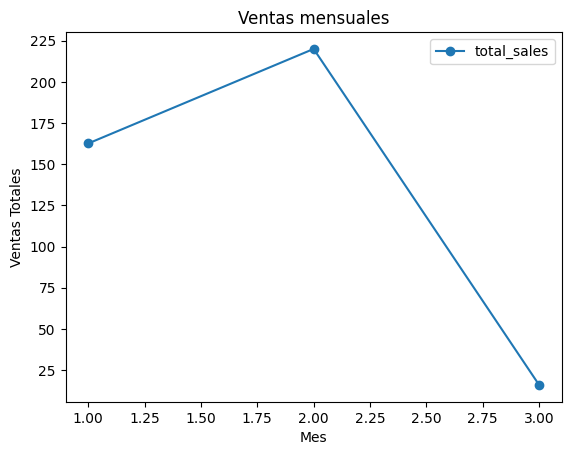

In [10]:
# Gráfico de lineas de ventas mensuales
monthly_sales = df.groupBy("month")\
.agg(round(spark_sum("sales"),2).alias("total_sales"))\
.orderBy("month")

monthly_sales.toPandas().plot(x="month", y="total_sales", kind="line", marker="o", title="Ventas mensuales", xlabel="Mes", ylabel="Ventas Totales")

<Axes: title={'center': 'Ventas por país'}, xlabel='País', ylabel='Ventas Totales'>

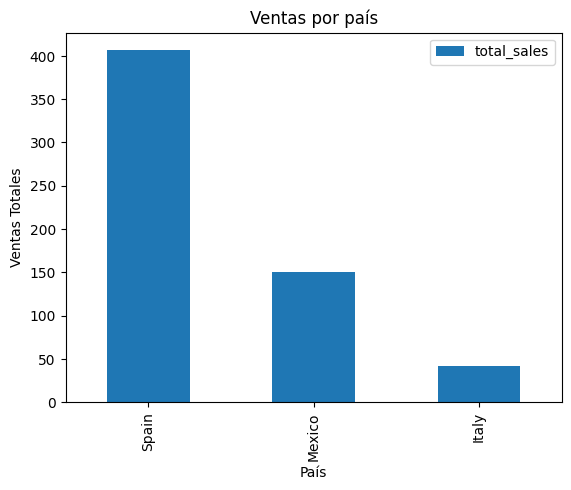

In [11]:
# Gráfico de barras de ventas por país
country_sales = df.groupBy("country")\
.agg(round(spark_sum("sales"),2).alias("total_sales"))\
.orderBy(desc("total_sales"))

country_sales.toPandas().plot(x="country", y="total_sales", kind="bar", title="Ventas por país", xlabel="País", ylabel="Ventas Totales")

In [12]:
spark.stop()